# Experiments Notebook
This notebook shows the results of different experiment discussed through our paper.<br> 
For experiments details and motivation refer to the paper.<br>
**important note**: you need to run *online_learning.ipynb* and *offline_learning.py* before running this file.<br>
As those files generate the predictions data required for comparison results


In [1]:
import util_fun as uf
import pandas as pd
import numpy as np
import torch.optim as optim
from cstm_models import build_mlp

In [2]:
# read the csv files and build the results dictionary
results = {}
model_names = ["offline_MLP","online_MLP","offline_LSTM", "offline_GRU",'offline_CNN','offline_logistic']
for name in model_names:
    df = pd.read_csv(f"results/testing/predictions_vs_true/{name}.csv")
    y_true = df['True'].values
    y_pred = df['Prediction'].values
    timestamps = pd.to_datetime(df['Timestamp']).values
    results[name] = (y_true, y_pred, timestamps)




============== FINAL COMPARISON ==============
offline_MLP          | RMSE=4.5522 | MAE=1.9164 | R²=0.8432
online_MLP           | RMSE=4.9743 | MAE=1.4029 | R²=0.8128
offline_LSTM         | RMSE=4.4307 | MAE=1.5807 | R²=0.8515
offline_GRU          | RMSE=4.3783 | MAE=2.0438 | R²=0.8550
offline_CNN          | RMSE=6.8992 | MAE=3.2655 | R²=0.6399
offline_logistic     | RMSE=5.0739 | MAE=2.1027 | R²=0.8052


Saved PNG: results/testing/exp_2\offline_all_models_vs_online.png


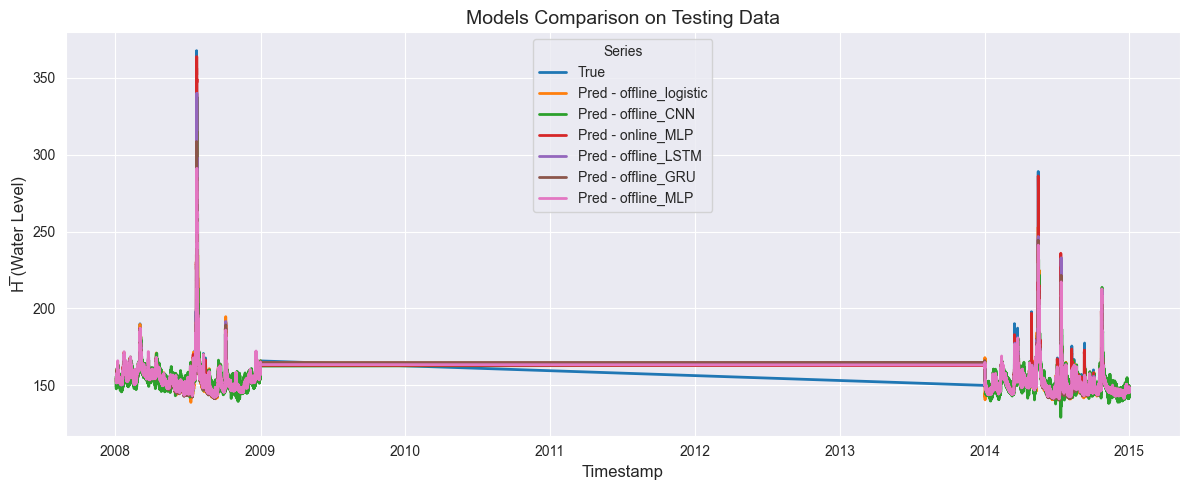

In [3]:
# ploting all the resuls together 
uf.calculate_metrics_and_plot(results, plot_title="Models Comparison on Testing Data",
                            export_html=True,
                            export_file_name= "results/testing/exp_2/offline_all_models_vs_online",
                            use_seaborn_plot=True)

### Experiment (1): Online vs Offline Comparison (MLP Model)

**Objective:** To test the performance of our online learning approach versus traditional offline learning using the same MLP model architecture and parameters. This experiment evaluates whether the online model can adapt better to flood peaks compared to offline models, despite potentially having higher overall error metrics. The focus is on understanding the trade-off between generalization (offline) and adaptability (online) to sudden environmental changes.



============== FINAL COMPARISON ==============
offline_MLP          | RMSE=4.5522 | MAE=1.9164 | R²=0.8432
online_MLP           | RMSE=4.9743 | MAE=1.4029 | R²=0.8128
offline_LSTM         | RMSE=4.4307 | MAE=1.5807 | R²=0.8515
offline_GRU          | RMSE=4.3783 | MAE=2.0438 | R²=0.8550
offline_CNN          | RMSE=6.8992 | MAE=3.2655 | R²=0.6399
offline_logistic     | RMSE=5.0739 | MAE=2.1027 | R²=0.8052


Saved PNG: results/testing/exp_1\offline_vs_online_MLP.png


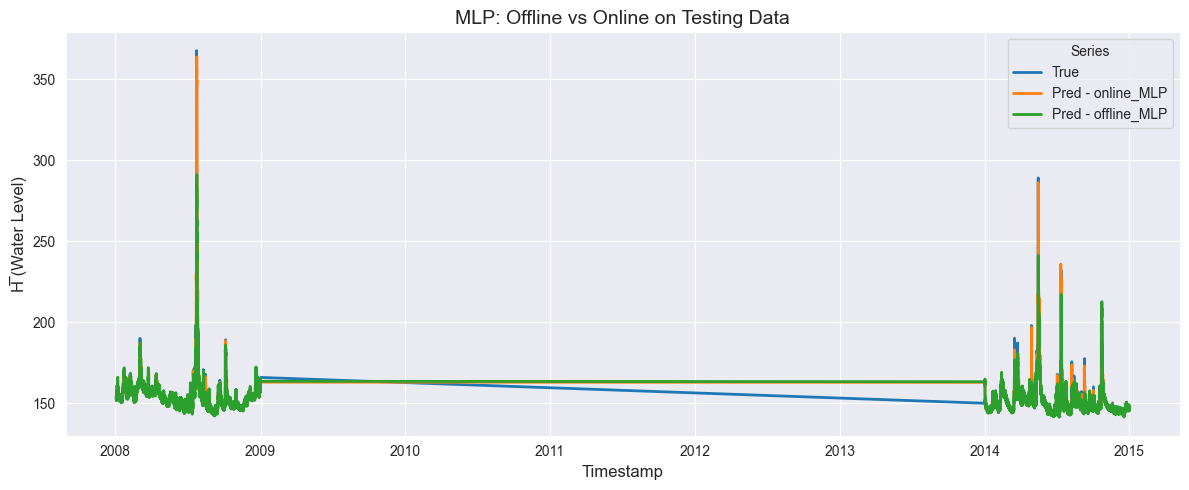

In [4]:
# Plot the online vs offline results 
uf.calculate_metrics_and_plot(results, plot_title="MLP: Offline vs Online on Testing Data",
                            export_file_name= 'results/testing/exp_1/offline_vs_online_MLP',
                            export_html=True,
                            use_seaborn_plot=True,
                            methods_to_plot=["offline_MLP","online_MLP"])

## Experiment (2): Online Model vs Standard Offline Architectures

**Objective:** To compare our online learning MLP model against widely used traditional and deep learning models (LSTM, GRU, CNN, and Logistic Regression) trained in offline fashion. This experiment evaluates the trade-off between peak value detection and overall prediction metrics. The goal is to understand whether our simple online MLP can outperform more complex offline architectures in capturing critical flood events, particularly in terms of sensitivity to sudden water level changes.



============== FINAL COMPARISON ==============
offline_MLP          | RMSE=4.5522 | MAE=1.9164 | R²=0.8432
online_MLP           | RMSE=4.9743 | MAE=1.4029 | R²=0.8128
offline_LSTM         | RMSE=4.4307 | MAE=1.5807 | R²=0.8515
offline_GRU          | RMSE=4.3783 | MAE=2.0438 | R²=0.8550
offline_CNN          | RMSE=6.8992 | MAE=3.2655 | R²=0.6399
offline_logistic     | RMSE=5.0739 | MAE=2.1027 | R²=0.8052


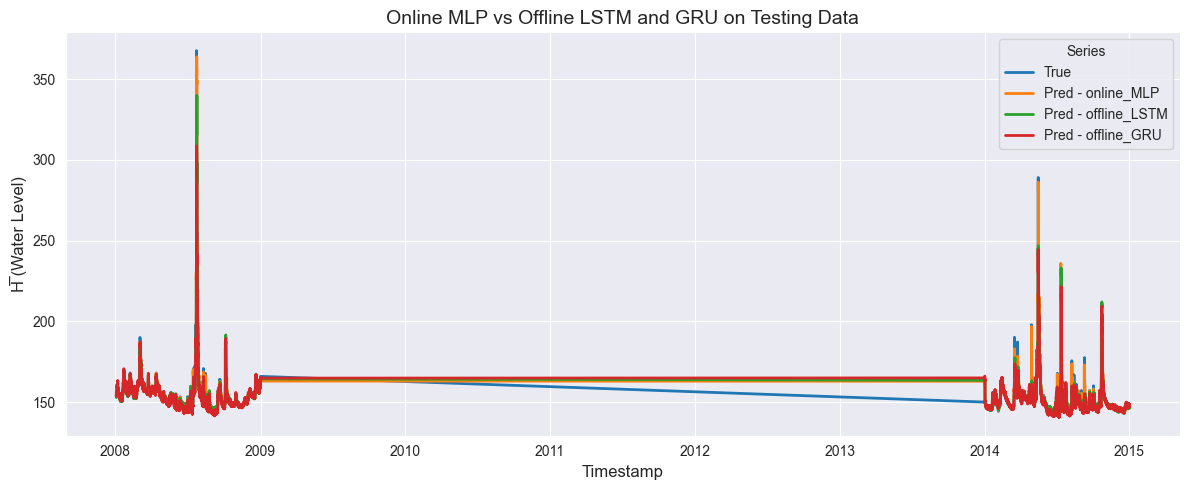

In [5]:
# Plot the online vs offline results 
uf.calculate_metrics_and_plot(results, plot_title="Online MLP vs Offline LSTM and GRU on Testing Data",
                            methods_to_plot=["offline_LSTM","offline_GRU",'online_MLP'])

## Experiment (3): Adaptive Optimizers Comparison

**Objective:** To evaluate the impact of different adaptive learning rate optimizers (Adam, AdamW, RMSProp, RAdam) and our custom "Amnesia" strategy on the online learning model's ability to balance stability and adaptability. Since online learning updates the model with only one optimization step per batch, the choice of optimizer is critical for rapid convergence and peak detection. This experiment investigates the trade-off between global prediction accuracy and sensitivity to extreme flood events, aiming to identify which optimizer best suits real-time flood warning systems.

In [6]:
# --- Define Model Parameters ---
LOOKBACK = 48   # 48 hours of historical data
HORIZON = 24    # 24 hours of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  # we are using batch size of 1 for time series
H_BAR_INDEX = 3 # H_bar is the 4th feature (index 3)
EPSILON = 1e-6  # For numerical stability in normalization

train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by oytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.core.frame.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)



Training with optimizer: Adam

Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.012740
   Batch 200/2461, Loss: 0.002794
   Batch 300/2461, Loss: 0.092152
   Batch 400/2461, Loss: 0.049120
   Batch 500/2461, Loss: 0.015098
   Batch 600/2461, Loss: 0.274561
   Batch 700/2461, Loss: 0.036709
   Batch 800/2461, Loss: 0.001721
   Batch 900/2461, Loss: 0.214993
   Batch 1000/2461, Loss: 0.163842
   Batch 1100/2461, Loss: 0.025557
   Batch 1200/2461, Loss: 0.058912
   Batch 1300/2461, Loss: 0.001186
   Batch 1400/2461, Loss: 0.125313
   Batch 1500/2461, Loss: 0.018355
   Batch 1600/2461, Loss: 0.056198
   Batch 1700/2461, Loss: 0.041292
   Batch 1800/2461, Loss: 0.076154
   Batch 1900/2461, Loss: 0.072046
   Batch 2000/2461, Loss: 0.102210
   Batch 2100/2461, Loss: 0.040416
   Batch 2200/2461, Loss: 0.021815
   Batch 2300/2461, Loss: 0.077875
   Batch 2400/2461, Loss: 0.004051
   Batch 2461/2461, Loss: 0.031187
Training complete.

Training with optimizer: AdamW

St

Saved PNG: results/training\Optimizers Comparison training.png


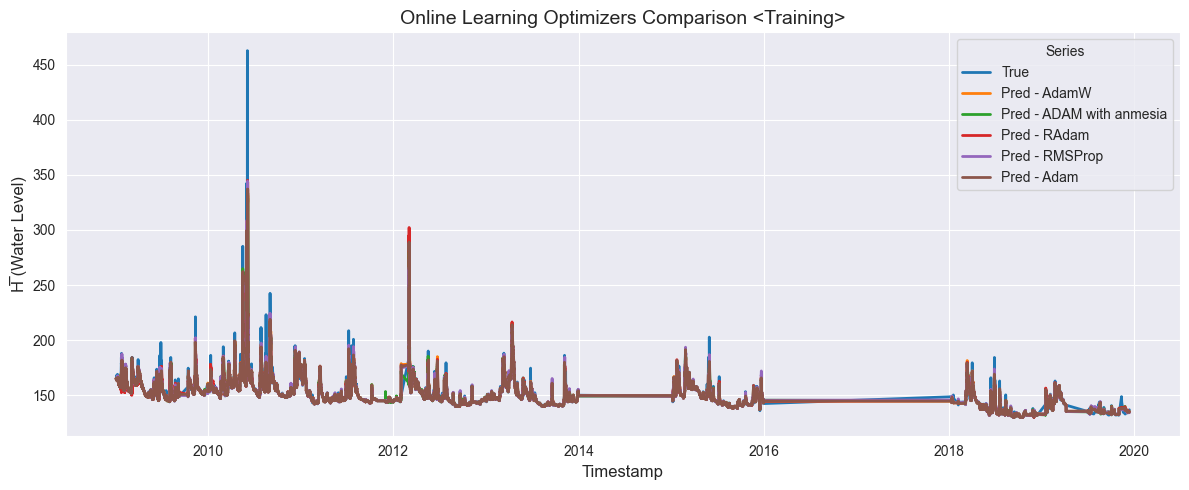

Appended metrics to CSV: results/training\Optimizers Comparison training.csv


In [7]:
# ---- List of Optimizers to Compare ----------------------------

def build_optimizers(model, lr=0.001):
    return {
        "Adam": optim.Adam(model.parameters(), lr=lr),
        "AdamW": optim.AdamW(model.parameters(), lr=lr),
        "RMSProp": optim.RMSprop(model.parameters(), lr=lr, alpha=0.9),
        "RAdam": optim.RAdam(model.parameters(), lr=lr),
        "ADAM with anmesia": optim.Adam(model.parameters(), lr=lr),
    }

results = {}
models_after_training = {}
optimizers_to_test = ["Adam", "AdamW", "RMSProp", "RAdam", "ADAM with anmesia"]
for opt_name in optimizers_to_test:
    print(f"\n==============================")
    print(f"Training with optimizer: {opt_name}")
    print(f"==============================")

    # Reinitialize a fresh model for each optimizer
    # create a new instance of the MLP model with adam them overwriting the optimizer by bild_optimizers call
    model_temp, _, criterion = build_mlp(LOOKBACK * N_FEATURES, HORIZON) 
    opt_dict = build_optimizers(model_temp)

    optimizer = opt_dict[opt_name]

    if opt_name == "ADAM with anmesia":
        enable_amnesia = True
    else:
        enable_amnesia = False
        
    y_true, y_pred, time_indices, batch_losses = uf.train_model_online(model_temp, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE,
                                                                              enable_amnesia, 7, 50, 0.1, 0.001)
    results[opt_name] = (y_true, y_pred, time_indices)
    models_after_training[opt_name] = model_temp
uf.calculate_metrics_and_plot(results,'Online Learning Optimizers Comparison <Training>',
                              export_metrics= True,
                              export_file_name='results/training/Optimizers Comparison training')



Evaluating model trained with optimizer: Adam
Testing complete.

Evaluating model trained with optimizer: AdamW
Testing complete.

Evaluating model trained with optimizer: RMSProp
Testing complete.

Evaluating model trained with optimizer: RAdam
Testing complete.

Evaluating model trained with optimizer: ADAM with anmesia
Testing complete.


============== FINAL COMPARISON ==============
Adam                 | RMSE=5.0667 | MAE=1.4220 | R²=0.8058
AdamW                | RMSE=5.0956 | MAE=1.4279 | R²=0.8036
RMSProp              | RMSE=4.3030 | MAE=1.2379 | R²=0.8599
RAdam                | RMSE=5.2389 | MAE=1.4510 | R²=0.7924
ADAM with anmesia    | RMSE=4.8928 | MAE=1.3728 | R²=0.8189


Saved PNG: results/testing/exp_3\optimizers_comparison_test.png


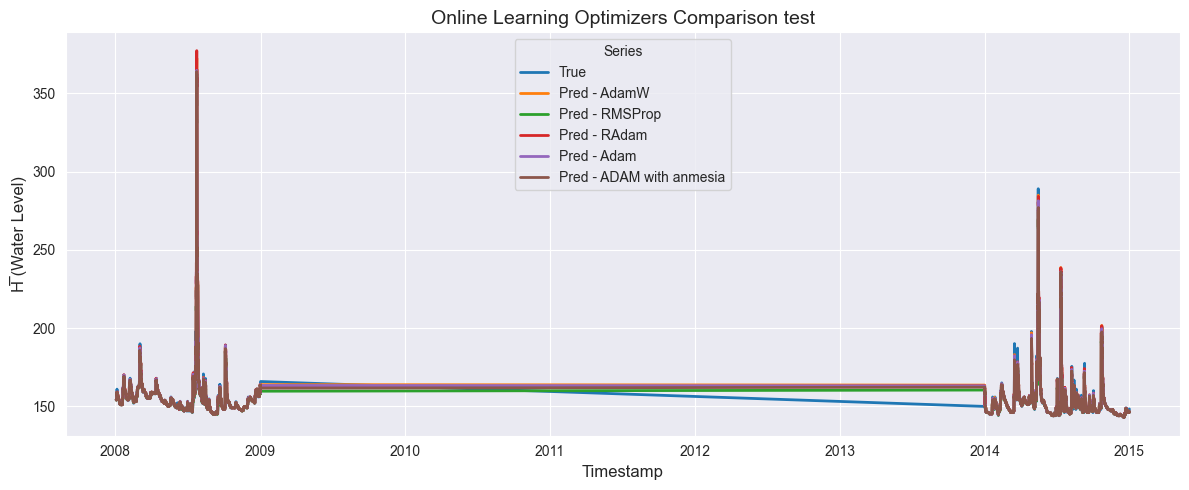

Appended metrics to CSV: results/testing/exp_3\optimizers_comparison_test.csv


In [8]:
results = {}
for opt_name, model in models_after_training.items():
    print(f"\n==============================")
    print(f"Evaluating model trained with optimizer: {opt_name}")
    print(f"==============================")
    
    y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
    results[opt_name] = (y_true_test, y_pred_test, time_indices_test)
uf.calculate_metrics_and_plot(results,'Online Learning Optimizers Comparison test',
                              export_metrics= True,
                              export_html=True,
                              export_file_name= 'results/testing/exp_3/optimizers_comparison_test',
                              use_seaborn_plot=True)



============== FINAL COMPARISON ==============
Adam                 | RMSE=5.0667 | MAE=1.4220 | R²=0.8058
AdamW                | RMSE=5.0956 | MAE=1.4279 | R²=0.8036
RMSProp              | RMSE=4.3030 | MAE=1.2379 | R²=0.8599
RAdam                | RMSE=5.2389 | MAE=1.4510 | R²=0.7924
ADAM with anmesia    | RMSE=4.8928 | MAE=1.3728 | R²=0.8189


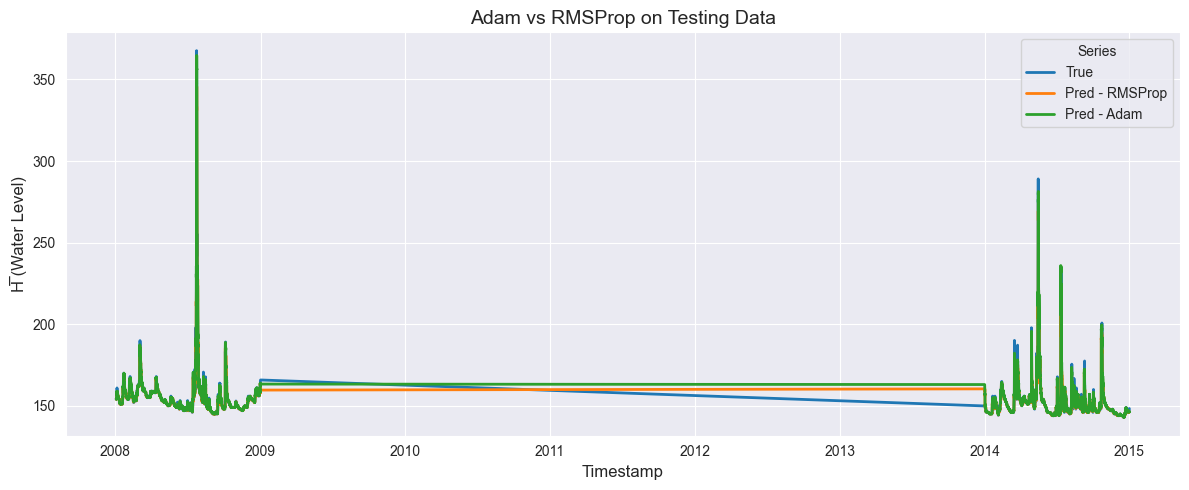

In [9]:
# just plot adam and RMSProp for simplicity
uf.calculate_metrics_and_plot(results,'Adam vs RMSProp on Testing Data',
                              methods_to_plot=["Adam", "RMSProp"])



============== FINAL COMPARISON ==============
Adam                 | RMSE=5.0667 | MAE=1.4220 | R²=0.8058
AdamW                | RMSE=5.0956 | MAE=1.4279 | R²=0.8036
RMSProp              | RMSE=4.3030 | MAE=1.2379 | R²=0.8599
RAdam                | RMSE=5.2389 | MAE=1.4510 | R²=0.7924
ADAM with anmesia    | RMSE=4.8928 | MAE=1.3728 | R²=0.8189


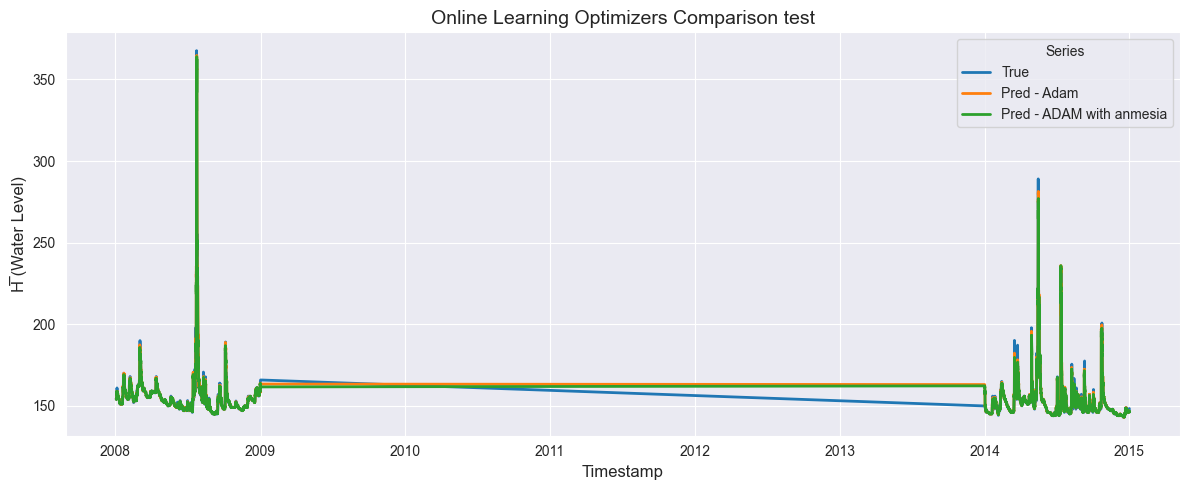

In [10]:
# just plot adam and adam with amnesia
uf.calculate_metrics_and_plot(results,'Online Learning Optimizers Comparison test',
                              methods_to_plot=["Adam", "ADAM with anmesia"])